## PyTorch Tensor 기초

In [2]:
import torch

X_batch = torch.tensor([
    [1.0, 2.0],
    [3.0, 4.0],
    [5.0, 6.0],
    [7.0, 8.0]
], dtype=torch.float32)

# torch.tensor(...)는 Python의 숫자나 리스트를 PyTorch 텐서로 변환하는 함수이다
# 신경망의 입력과 가중치는 일반적으로 float32를 사용한다

y_batch = torch.tensor([
    [0.0],
    [1.0],
    [1.0],
    [0.0]
], dtype=torch.float32)

In [3]:
print(X_batch)
print("X shape:", X_batch.shape) # shape() 아님!! 말 그대로 shape을 알려줌
print("X dtype:", X_batch.dtype) # 어떤 자료형의 숫자를 저장하는지 알려줌
print("X ndim:", X_batch.ndim) # 텐서가 몇 차원인지 알려준다

print()

print(y_batch)
print("y shape:", y_batch.shape)
print("y dtype:", y_batch.dtype)
print("y ndim:", y_batch.ndim)

tensor([[1., 2.],
        [3., 4.],
        [5., 6.],
        [7., 8.]])
X shape: torch.Size([4, 2])
X dtype: torch.float32
X ndim: 2

tensor([[0.],
        [1.],
        [1.],
        [0.]])
y shape: torch.Size([4, 1])
y dtype: torch.float32
y ndim: 2


## PyTorch 문법

Indexing: `Tensor[row, column]`

즉 위의 예시에서 `X_batch[0, 1] = 2.0`이다

<br>

## 정수 index와 slice의 차이

index

`a = X_batch[0]`

0은 정수 index이다. 첫 번째 row를 꺼내면서 row 차원이 사라진다.

dim: (2,)

output: `tensor([1., 2.])`

slice

`b = X_batch[0:1]`

0:1은 slice이다. 즉 0번 row를 선택하지만, row 차원을 유지한다.

dim: (1,2)

output: `tensor([[1., 2.]])`

**예제로 차이점 알아보기**

```python
X_batch[:, 0]

tensor([1., 3., 5., 7.])

X_batch[:, 0:1]

tensor([
    [1.],
    [3.],
    [5.],
    [7.]
])
```

In [4]:
a = X_batch[0]
b = X_batch[0:1]
c = X_batch[:, 0]
d = X_batch[:, 0:1]

print("a:", a)
print("a shape:", a.shape)

print("\nb:", b)
print("b shape:", b.shape)

print("\nc:", c)
print("c shape:", c.shape)

print("\nd:", d)
print("d shape:", d.shape)

a: tensor([1., 2.])
a shape: torch.Size([2])

b: tensor([[1., 2.]])
b shape: torch.Size([1, 2])

c: tensor([1., 3., 5., 7.])
c shape: torch.Size([4])

d: tensor([[1.],
        [3.],
        [5.],
        [7.]])
d shape: torch.Size([4, 1])


### 사라진 dimension 다시 만들기

```python
c = X_batch[:, 0]
tensor([1., 3., 5., 7.])
c.shape = (4,)
```

<br>

**unsqueeze()** 를 사용하여 되돌릴 수 있다.

<br>

```c_column = c.unsqueeze(dim=1)```

`c_column.shape = (4, 1)`

unsqueeze()는 크기가 1인 새로운 dimension을 추가한다

squeeze()는 정확히 반대 연산이다

```python
c                : (4,)
c.unsqueeze(0)   : (1, 4)
c.unsqueeze(1)   : (4, 1)
```

괄호는 새 dimension을 어느 위치에 넣을 것인지를 지정한다

dim = 0 이면 앞에 추가, dim =  1이면 뒤에 추가한다 (정확히는 dim = 1 위치에 삽입한다)

In [5]:
c = X_batch[:, 0]

c_row = c.unsqueeze(dim=0)
c_column = c.unsqueeze(dim=1)
c_restored = c_column.squeeze(dim=1)

print("c:", c.shape)
print("unsqueeze dim=0:", c_row.shape)
print("unsqueeze dim=1:", c_column.shape)
print("squeeze dim=1:", c_restored.shape)

c: torch.Size([4])
unsqueeze dim=0: torch.Size([1, 4])
unsqueeze dim=1: torch.Size([4, 1])
squeeze dim=1: torch.Size([4])


### Matrix Multiplication

Z1 = X_batch @ W1 + b1

여기서 @는 matrix multiplication이다

$$
(4,2)@(2,8)=(4,8)
$$

그다음 b1.shape는 (8,)이지만 PyTorch의 broadcasting을 통해 네 sample에 동일하게 더해진다

In [6]:
W1 = torch.randn(2, 8)
b1 = torch.zeros(8)
Z1 = X_batch @ W1 + b1

b1의 8개 element는 Z1의 feature dimension과 대응되고, 같은 b1이 batch dimension의 모든 sample에 broadcasting된다.

### Weight 생성

In [7]:
torch.manual_seed(42)

W1 = torch.randn(2, 8) * 0.1
b1 = torch.zeros(8)

Z1 = X_batch @ W1 + b1
A1 = torch.relu(Z1)

print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("Z1 shape:", Z1.shape)
print("A1 shape:", A1.shape)

print("\nZ1 first sample:")
print(Z1[0])

print("\nA1 first sample:")
print(A1[0])

W1 shape: torch.Size([2, 8])
b1 shape: torch.Size([8])
Z1 shape: torch.Size([4, 8])
A1 shape: torch.Size([4, 8])

Z1 first sample:
tensor([ 0.0423,  0.4785,  0.0116, -0.4913, -0.0777, -0.2353, -0.1581, -0.0080])

A1 first sample:
tensor([0.0423, 0.4785, 0.0116, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000])


In [8]:
import torch

torch.manual_seed(42)

Numpy의 `rng = np.random.default_rng(42)`와 같다

In [9]:
W1 = torch.randn(2, 8) * 0.1
print(W1)
print("W1 shape:", W1.shape)
print("W1 dtype:", W1.dtype)

tensor([[ 0.1927,  0.1487,  0.0901, -0.2106,  0.0678, -0.1235, -0.0043, -0.1605],
        [-0.0752,  0.1649, -0.0392, -0.1404, -0.0728, -0.0559, -0.0769,  0.0762]])
W1 shape: torch.Size([2, 8])
W1 dtype: torch.float32


In [10]:
b1 = torch.zeros(8) # bias 생성

Z1 = X_batch @ W1 + b1
A1 = torch.relu(Z1) # ReLU

print("b1:", b1.shape)
print("Z1:", Z1.shape)
print("A1:", A1.shape)

print("\nZ1[0]:", Z1[0])
print("A1[0]:", A1[0])

b1: torch.Size([8])
Z1: torch.Size([4, 8])
A1: torch.Size([4, 8])

Z1[0]: tensor([ 0.0423,  0.4785,  0.0116, -0.4913, -0.0777, -0.2353, -0.1581, -0.0080])
A1[0]: tensor([0.0423, 0.4785, 0.0116, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000])


In [11]:
W2 = torch.randn(8, 1) * 0.1
b2 = torch.zeros(1)

Z2 = A1 @ W2 + b2
Y_hat = torch.sigmoid(Z2) # 시그모이드

criterion = torch.nn.BCELoss() # BCE Loss를 깔끔하게 계산할 수 있다
loss = criterion(Y_hat, y_batch) 

print("W2:", W2.shape)
print("b2:", b2.shape)
print("Z2:", Z2.shape)
print("Y_hat:", Y_hat.shape)
print("loss:", loss)
print("loss shape:", loss.shape)
print("Python number:", loss.item()) # Scalar Tensor에서 Python 숫자 하나를 꺼낸다 (일반 숫자)

W2: torch.Size([8, 1])
b2: torch.Size([1])
Z2: torch.Size([4, 1])
Y_hat: torch.Size([4, 1])
loss: tensor(0.6938)
loss shape: torch.Size([])
Python number: 0.693844735622406


In [12]:
import numpy as np
import torch

# 1. 이전과 동일한 dataset 생성
DATA_SEED = 42
rng = np.random.default_rng(DATA_SEED)

centers = np.array([
    [-1.0, -1.0],
    [-1.0,  1.0],
    [ 1.0, -1.0],
    [ 1.0,  1.0],
])

center_labels = np.array([0, 1, 1, 0])

X_parts = []
y_parts = []

for center, label in zip(centers, center_labels):
    points = center + rng.normal(
        loc=0.0,
        scale=0.25,
        size=(100, 2),
    )

    labels = np.full(
        (100, 1),
        label,
        dtype=float,
    )

    X_parts.append(points)
    y_parts.append(labels)

X = np.vstack(X_parts)
y = np.vstack(y_parts)

# 2. 이전과 동일한 train/validation split
SPLIT_SEED = 123
split_rng = np.random.default_rng(SPLIT_SEED)

indices = split_rng.permutation(len(X))
split_index = int(len(X) * 0.8)

train_indices = indices[:split_index]
val_indices = indices[split_index:]

# 3. NumPy array → PyTorch tensor

# torch.tensor(): NumPy array를 PyTorch tensor로 변환한다

X_train = torch.tensor(
    X[train_indices],
    dtype=torch.float32,
)

y_train = torch.tensor(
    y[train_indices],
    dtype=torch.float32,
)

X_val = torch.tensor(
    X[val_indices],
    dtype=torch.float32,
)

y_val = torch.tensor(
    y[val_indices],
    dtype=torch.float32,
)

print("X_train:", X_train.shape, X_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("X_val:", X_val.shape, X_val.dtype)
print("y_val:", y_val.shape, y_val.dtype)

X_train: torch.Size([320, 2]) torch.float32
y_train: torch.Size([320, 1]) torch.float32
X_val: torch.Size([80, 2]) torch.float32
y_val: torch.Size([80, 1]) torch.float32


In [13]:
class BinaryMLP(torch.nn.Module):
    def __init__(self): # __init__()에서는 model을 구성한다
        super().__init__() # torch.nn.Module이 제공하는 model 관리 기능을 초기화한다
        # MIT 6.S191 note에 왜 Super Method를 쓰는지 자세히 적어둠

        self.fc1 = torch.nn.Linear(2, 8)
        self.relu = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(8, 1)

    def forward(self, X): # forward()에서는 input이 model을 통과하는 순서를 정의한다
        Z1 = self.fc1(X)
        A1 = self.relu(Z1)
        logits = self.fc2(A1)

        return logits

핵심 대응
```python
self.fc1(X)   ↔ X @ W1 + b1
self.relu(Z1) ↔ torch.relu(Z1)
self.fc2(A1)  ↔ A1 @ W2 + b2
```

In [14]:
torch.manual_seed(42)

model = BinaryMLP()

print(model)
print("fc1 weight:", model.fc1.weight.shape)
print("fc1 bias:", model.fc1.bias.shape)
print("fc2 weight:", model.fc2.weight.shape)
print("fc2 bias:", model.fc2.bias.shape)

BinaryMLP(
  (fc1): Linear(in_features=2, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)
fc1 weight: torch.Size([8, 2])
fc1 bias: torch.Size([8])
fc2 weight: torch.Size([1, 8])
fc2 bias: torch.Size([1])


여기서 PyTorch `nn.Linear`의 weight shape는 수동 NumPy weight와 반대 순서이다

```text
수동 W1:             (input, output) = (2, 8)
nn.Linear weight:     (output, input) = (8, 2)
```

하지만 `self.fc1(X)`가 내부에서 transpose를 처리하므로 직접 transpose할 필요는 없다

In [15]:
logits = model(X_train)

print("input:", X_train.shape)
print("logits:", logits.shape)
print("first logits:", logits[:5])

input: torch.Size([320, 2])
logits: torch.Size([320, 1])
first logits: tensor([[-0.1324],
        [-0.6575],
        [-0.5873],
        [-0.0941],
        [ 0.2006]], grad_fn=<SliceBackward0>)


### Loss와 optimizer 생성

In [16]:
criterion = torch.nn.BCEWithLogitsLoss() 
# sigmoid와 BCE Loss를 함께 계산한다, 따라서 logits에 직접 적용하며, 별도로 sigmoid를 넣지 않음

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1,
)



### Training loop

In [17]:
train_loss_history = []

for epoch in range(1000):
    model.train()

    optimizer.zero_grad()

    logits = model(X_train)
    loss = criterion(logits, y_train)

    loss.backward()
    optimizer.step()

    train_loss_history.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(
            f"epoch {epoch + 1:4d} | "
            f"loss {loss.item():.6f}"
        )

epoch  100 | loss 0.346938
epoch  200 | loss 0.119421
epoch  300 | loss 0.052671
epoch  400 | loss 0.031292
epoch  500 | loss 0.021750
epoch  600 | loss 0.016538
epoch  700 | loss 0.013279
epoch  800 | loss 0.011064
epoch  900 | loss 0.009466
epoch 1000 | loss 0.008263


### 코드 분석

1. optimizer.zero_grad()  → 이전 gradient 제거

2. model(X_train)         → forward

3. criterion(...)         → loss 계산

4. loss.backward()        → gradient 계산

5. optimizer.step()       → parameter update

model.parameters()를 optimizer에 전달했기 때문에 step()이 fc1, fc2의 weight와 bias를 모두 업데이트한다

In [ ]:
def evaluate(model, X, y):
    model.eval() # model을 evaluation mode로 전환한다

    with torch.no_grad(): # evaluation 중에는 gradient와 autograd graph를 만들지 않는다
        logits = model(X)
        loss = criterion(logits, y).item()

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float() # 확률을 class로 변환한다  -> class 0: <0.5, class 1: >=0.5

        accuracy = (
            (predictions == y)
            .float()
            .mean()
            .item()
        )

    return loss, accuracy

### Train과 validation 평가

In [19]:
train_loss, train_accuracy = evaluate(
    model,
    X_train,
    y_train,
)

val_loss, val_accuracy = evaluate(
    model,
    X_val,
    y_val,
)

print(f"train loss: {train_loss:.6f}")
print(f"train accuracy: {train_accuracy:.4f}")

print(f"validation loss: {val_loss:.6f}")
print(f"validation accuracy: {val_accuracy:.4f}")

train loss: 0.008252
train accuracy: 1.0000
validation loss: 0.006746
validation accuracy: 1.0000


### PyTorch weight를 Numpy로 변환

In [20]:
W1_np = model.fc1.weight.detach().numpy().T.copy()
b1_np = model.fc1.bias.detach().numpy().reshape(1, -1).copy()

W2_np = model.fc2.weight.detach().numpy().T.copy() # PyTorch weight를 기존 NumPy형식으로 돌려 놓는다
b2_np = model.fc2.bias.detach().numpy().reshape(1, -1).copy()

X_np = X_train.detach().numpy()
y_np = y_train.detach().numpy()

# .detach는 tensor를 autograd graph에서 분리한다

print("W1 NumPy:", W1_np.shape)
print("b1 NumPy:", b1_np.shape)
print("W2 NumPy:", W2_np.shape)
print("b2 NumPy:", b2_np.shape)

W1 NumPy: (2, 8)
b1 NumPy: (1, 8)
W2 NumPy: (8, 1)
b2 NumPy: (1, 1)


### NumPy Forward

In [21]:
Z1_np = X_np @ W1_np + b1_np
A1_np = np.maximum(0, Z1_np)

Z2_np = A1_np @ W2_np + b2_np
Y_hat_np = 1 / (1 + np.exp(-Z2_np))

epsilon = 1e-7

loss_np = -np.mean(
    y_np * np.log(Y_hat_np + epsilon)
    + (1 - y_np) * np.log(1 - Y_hat_np + epsilon)
)

### PyTorch 결과와 비교

In [22]:
model.eval()

with torch.no_grad():
    logits_torch = model(X_train)
    loss_torch = criterion(logits_torch, y_train)

logit_difference = np.max(
    np.abs(
        Z2_np
        - logits_torch.numpy()
    )
)

loss_difference = abs(
    loss_np
    - loss_torch.item()
)

print("NumPy loss:", loss_np)
print("PyTorch loss:", loss_torch.item())
print("maximum logit difference:", logit_difference)
print("loss difference:", loss_difference)

NumPy loss: 0.008251937
PyTorch loss: 0.00825204886496067
maximum logit difference: 1.4305115e-06
loss difference: 1.1175871e-07


### NumPy manual backward

In [24]:
B = X_np.shape[0]

# Second layer
dZ2_np = (Y_hat_np - y_np) / B # BCEWithLogitsLoss가 batch loss의 mean을 사용하기 때문이다

dW2_np = A1_np.T @ dZ2_np
db2_np = np.sum(
    dZ2_np,
    axis=0,
    keepdims=True,
)

# ReLU와 first layer
dA1_np = dZ2_np @ W2_np.T
dZ1_np = dA1_np * (Z1_np > 0)

dW1_np = X_np.T @ dZ1_np
db1_np = np.sum(
    dZ1_np,
    axis=0,
    keepdims=True,
)

### PyTorch autograd 다시 계산

In [25]:
model.zero_grad()

logits_torch = model(X_train)
loss_torch = criterion(logits_torch, y_train)

loss_torch.backward()

### 결과 비교

In [26]:
checks = {
    "W1": torch.allclose(
        model.fc1.weight.grad,
        torch.tensor(dW1_np.T),
        atol=1e-6,
    ),
    "b1": torch.allclose(
        model.fc1.bias.grad,
        torch.tensor(db1_np.ravel()),
        atol=1e-6,
    ),
    "W2": torch.allclose(
        model.fc2.weight.grad,
        torch.tensor(dW2_np.T),
        atol=1e-6,
    ),
    "b2": torch.allclose(
        model.fc2.bias.grad,
        torch.tensor(db2_np.ravel()),
        atol=1e-6,
    ),
}

for name, passed in checks.items():
    print(name, passed)

W1 True
b1 True
W2 True
b2 True


In [27]:
print(
    "W1 maximum difference:",
    np.max(
        np.abs(
            model.fc1.weight.grad.detach().numpy()
            - dW1_np.T
        )
    )
)

print(
    "W2 maximum difference:",
    np.max(
        np.abs(
            model.fc2.weight.grad.detach().numpy()
            - dW2_np.T
        )
    )
)

W1 maximum difference: 6.9849193e-10
W2 maximum difference: 5.820766e-10


### 결과정리

In [29]:
import matplotlib.pyplot as plt
from pathlib import Path

# Decision boundary용 grid
x1_min = X[:, 0].min() - 0.5
x1_max = X[:, 0].max() + 0.5
x2_min = X[:, 1].min() - 0.5
x2_max = X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300),
)

grid_np = np.c_[
    xx.ravel(),
    yy.ravel(),
].astype(np.float32)

grid_tensor = torch.tensor(grid_np)

model.eval()

with torch.no_grad():
    grid_probabilities = torch.sigmoid(
        model(grid_tensor)
    )

grid_probabilities = (
    grid_probabilities
    .reshape(xx.shape)
    .numpy()
)

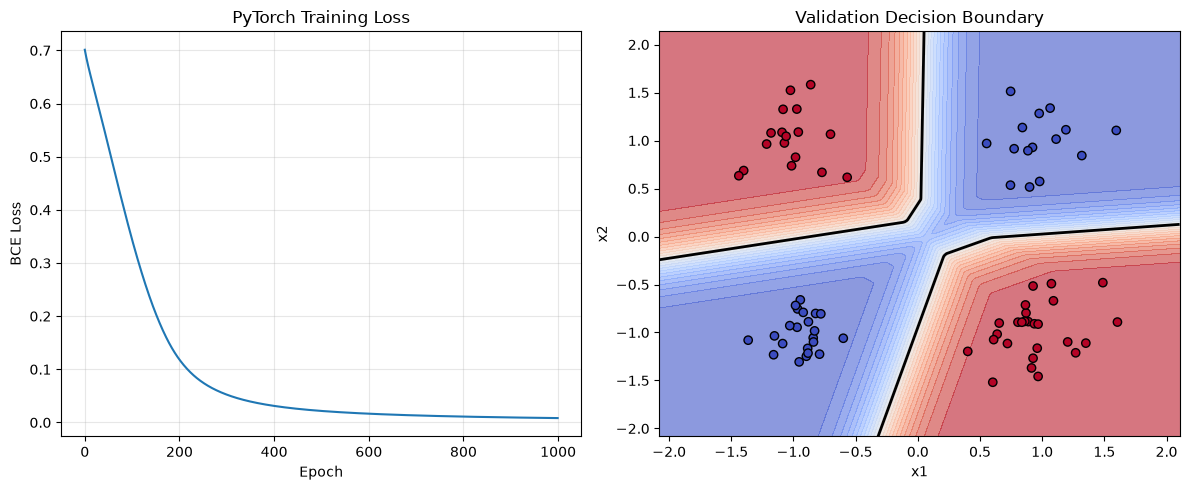

saved: /Users/meliday/Personal/AI Study/MITDeepLearning-6.S191/study_free/notes/pytorch_classifier_result.png


In [30]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
)

# Learning curve
axes[0].plot(train_loss_history)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].set_title("PyTorch Training Loss")
axes[0].grid(alpha=0.3)

# Decision boundary
axes[1].contourf(
    xx,
    yy,
    grid_probabilities,
    levels=30,
    cmap="coolwarm",
    alpha=0.6,
)

axes[1].contour(
    xx,
    yy,
    grid_probabilities,
    levels=[0.5],
    colors="black",
    linewidths=2,
)

axes[1].scatter(
    X_val[:, 0].numpy(),
    X_val[:, 1].numpy(),
    c=y_val.numpy().ravel(),
    cmap="coolwarm",
    edgecolors="black",
)

axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].set_title("Validation Decision Boundary")

plt.tight_layout()

output_path = Path(
    "pytorch_classifier_result.png"
)

plt.savefig(
    output_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print("saved:", output_path.resolve())

Manual weight       → nn.Linear

Manual ReLU         → nn.ReLU

Manual BCE          → BCEWithLogitsLoss

Manual gradient     → loss.backward()

Manual update       → optimizer.step()